# ChurnGuard — Exploratory Data Analysis

**Goal:** Understand the structure, distributions, and relationships in the customer churn dataset before modelling.

| Section | Focus |
|---|---|
| 1 | Setup & data loading |
| 2 | Dataset overview |
| 3 | Churn distribution |
| 4 | Numerical feature distributions |
| 5 | Categorical feature analysis |
| 6 | Bivariate analysis — features vs churn |
| 7 | Correlation & multicollinearity |
| 8 | Customer segmentation insights |
| 9 | Key findings & modelling implications |

## 1 · Setup & Data Loading

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# Make project root importable from notebooks/
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# ── Style ────────────────────────────────────────────────────────────────────
DARK_BG   = '#0e1117'
CARD_BG   = '#1e2130'
PRIMARY   = '#7c3aed'
DANGER    = '#ef4444'
SUCCESS   = '#10b981'
WARNING   = '#f59e0b'
INFO      = '#3b82f6'
TEXT      = '#cdd6f4'
MUTED     = '#8892b0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   CARD_BG,
    'axes.edgecolor':   MUTED,
    'axes.labelcolor':  TEXT,
    'axes.titlecolor':  TEXT,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'text.color':       TEXT,
    'grid.color':       '#2d3348',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': CARD_BG,
    'legend.edgecolor': MUTED,
    'figure.dpi':       120,
})
sns.set_palette([PRIMARY, DANGER, SUCCESS, WARNING, INFO, MUTED])

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
DATA_PATH = '../data/raw/customers.csv'

if not os.path.exists(DATA_PATH):
    print('Dataset not found — generating…')
    from scripts.generate_data import generate_customers
    os.makedirs('../data/raw', exist_ok=True)
    df_raw = generate_customers()
    df_raw.to_csv(DATA_PATH, index=False)
    print(f'Generated {len(df_raw):,} rows → {DATA_PATH}')

df = pd.read_csv(DATA_PATH)

# Normalise types
df['senior_citizen'] = df['senior_citizen'].astype(int)
df['tenure']         = pd.to_numeric(df['tenure'], errors='coerce')
df['monthly_charges']= pd.to_numeric(df['monthly_charges'], errors='coerce')
df['total_charges']  = pd.to_numeric(df['total_charges'], errors='coerce')
if df['churn'].dtype == object:
    df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
df['churn'] = df['churn'].astype(int)

# Derived features
SERVICE_COLS = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines',
]
df['service_count'] = sum((df[c] == 'Yes').astype(int) for c in SERVICE_COLS)
df['tenure_group']  = pd.cut(
    df['tenure'].fillna(0),
    bins=[-1, 12, 24, 48, 72],
    labels=['0–12 mo', '13–24 mo', '25–48 mo', '49–72 mo']
)

NUM_COLS = ['tenure', 'monthly_charges', 'total_charges', 'service_count']
CAT_COLS = [
    'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
    'multiple_lines', 'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
    'contract', 'paperless_billing', 'payment_method',
]

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')

Loaded 7,043 rows × 23 columns


## 2 · Dataset Overview

In [3]:
print('=' * 55)
print(f"  Rows          : {len(df):,}")
print(f"  Columns       : {df.shape[1]}")
print(f"  Churn rate    : {df['churn'].mean() * 100:.1f}%  ({df['churn'].sum():,} churned)")
print(f"  Missing vals  : {df.isnull().sum().sum()}")
print('=' * 55)
df.info()

  Rows          : 7,043
  Columns       : 23
  Churn rate    : 11.0%  (773 churned)
  Missing vals  : 78
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        7043 non-null   object  
 1   gender             7043 non-null   object  
 2   senior_citizen     7043 non-null   int32   
 3   partner            7043 non-null   object  
 4   dependents         7043 non-null   object  
 5   tenure             7043 non-null   int64   
 6   phone_service      7043 non-null   object  
 7   multiple_lines     7043 non-null   object  
 8   internet_service   7043 non-null   object  
 9   online_security    7043 non-null   object  
 10  online_backup      7043 non-null   object  
 11  device_protection  7043 non-null   object  
 12  tech_support       7043 non-null   object  
 13  streaming_tv       7043 non-null   object  
 14 

In [4]:
df[NUM_COLS].describe().round(2)

,tenure,monthly_charges,total_charges,service_count
count,7043.00,7043.00,6965.00,7043.00
mean,36.04,50.25,1805.40,2.02
std,20.89,17.26,1261.63,1.41
min,0.00,18.00,0.00,0.00
25%,18.00,36.46,775.43,1.00
50%,36.00,53.16,1556.26,2.00
75%,54.00,63.34,2690.39,3.00
max,72.00,95.89,6274.52,7.00


In [5]:
# Missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print('No missing values except expected total_charges NaN (new customers).')
else:
    print(missing.to_string())

total_charges    78


## 3 · Churn Distribution

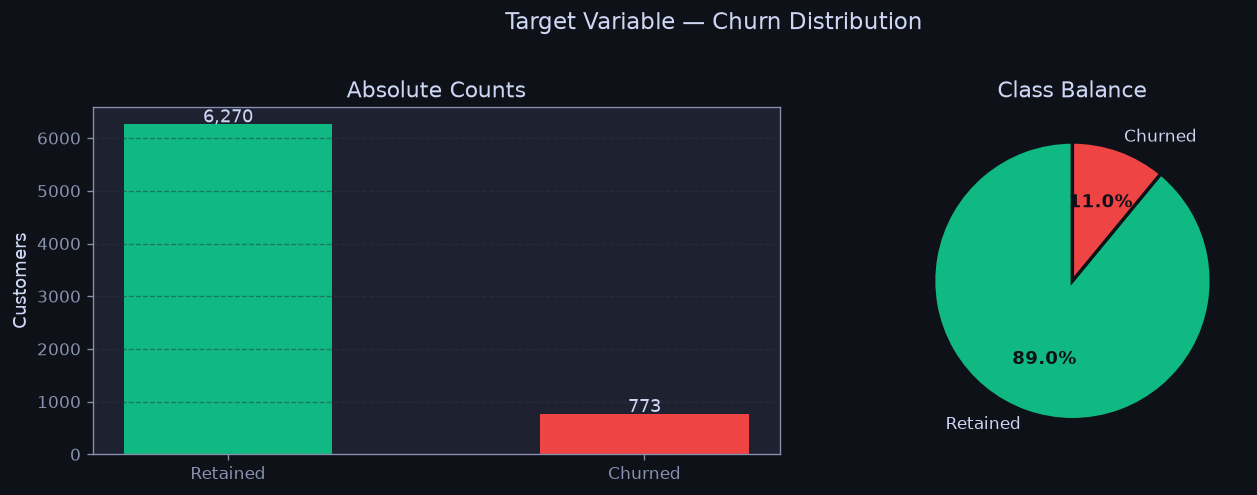

Class imbalance ratio  : 8.1:1  (retained:churned)
Minority class weight  : 11.0%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable — Churn Distribution', fontsize=14, color=TEXT, y=1.02)

counts = df['churn'].value_counts()
labels = ['Retained', 'Churned']
colors = [SUCCESS, DANGER]

# Bar chart
axes[0].bar(labels, [counts[0], counts[1]], color=colors, width=0.5)
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=11, color=TEXT)
axes[0].set_title('Absolute Counts')
axes[0].set_ylabel('Customers')
axes[0].grid(axis='y')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    [counts[0], counts[1]],
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 2},
)
for t in autotexts:
    t.set_color(DARK_BG)
    t.set_fontsize(11)
    t.set_fontweight('bold')
axes[1].set_facecolor(DARK_BG)
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_churn_dist.png', bbox_inches='tight')
plt.show()

print(f"Class imbalance ratio  : {counts[0]/counts[1]:.1f}:1  (retained:churned)")
print(f"Minority class weight  : {counts[1]/len(df)*100:.1f}%")

## 4 · Numerical Feature Distributions

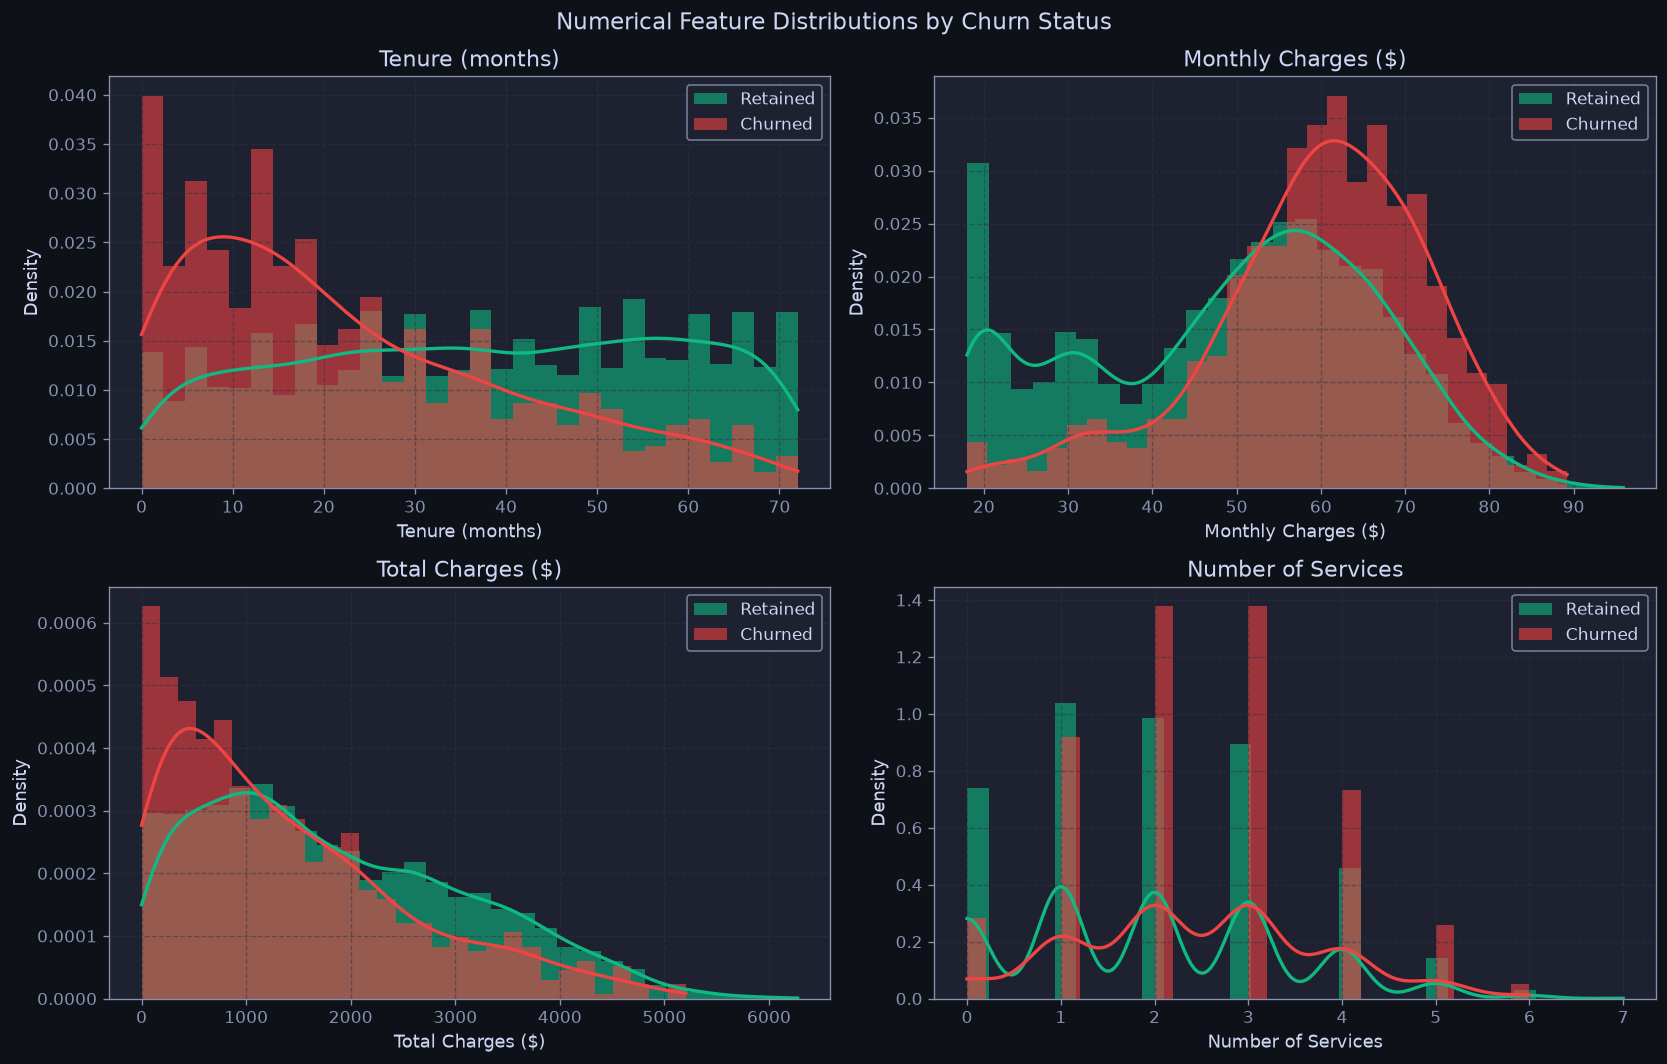

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Numerical Feature Distributions by Churn Status', fontsize=14, color=TEXT)
axes = axes.flatten()

num_features = [
    ('tenure',          'Tenure (months)'),
    ('monthly_charges', 'Monthly Charges ($)'),
    ('total_charges',   'Total Charges ($)'),
    ('service_count',   'Number of Services'),
]

for ax, (col, label) in zip(axes, num_features):
    retained = df.loc[df['churn'] == 0, col].dropna()
    churned  = df.loc[df['churn'] == 1, col].dropna()

    ax.hist(retained, bins=30, alpha=0.6, color=SUCCESS, label='Retained', density=True)
    ax.hist(churned,  bins=30, alpha=0.6, color=DANGER,  label='Churned',  density=True)

    # KDE overlay
    for data, color in [(retained, SUCCESS), (churned, DANGER)]:
        if len(data) > 1:
            kde_x = np.linspace(data.min(), data.max(), 200)
            kde   = stats.gaussian_kde(data)
            ax.plot(kde_x, kde(kde_x), color=color, lw=2)

    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_num_dist.png', bbox_inches='tight')
plt.show()

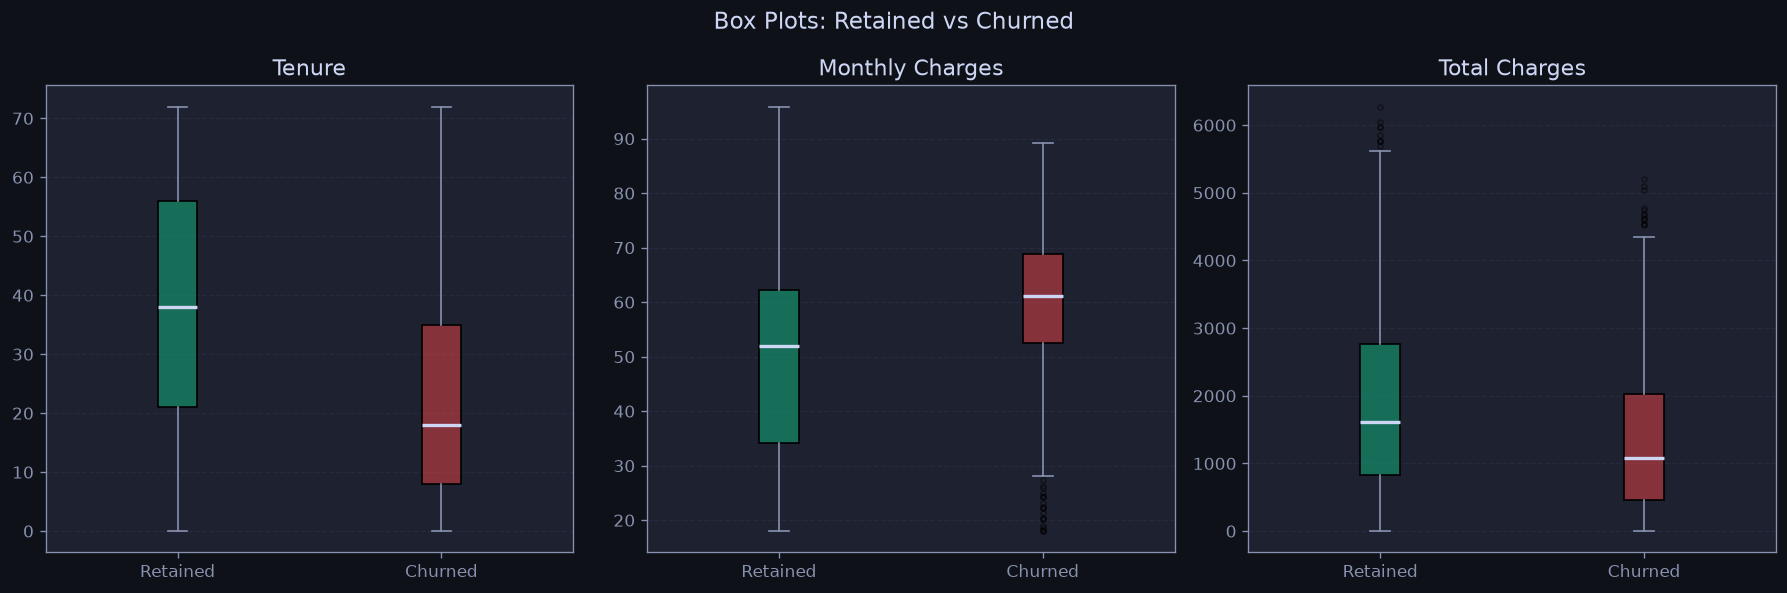

In [8]:
# Box plots — side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Box Plots: Retained vs Churned', fontsize=14, color=TEXT)

for ax, col in zip(axes, ['tenure', 'monthly_charges', 'total_charges']):
    data_plot = [
        df.loc[df['churn'] == 0, col].dropna(),
        df.loc[df['churn'] == 1, col].dropna(),
    ]
    bp = ax.boxplot(
        data_plot,
        tick_labels=['Retained', 'Churned'],
        patch_artist=True,
        medianprops={'color': TEXT, 'linewidth': 2},
        whiskerprops={'color': MUTED},
        capprops={'color': MUTED},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    )
    bp['boxes'][0].set_facecolor(SUCCESS + '80')
    bp['boxes'][1].set_facecolor(DANGER  + '80')
    ax.set_title(col.replace('_', ' ').title())
    ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_boxplots.png', bbox_inches='tight')
plt.show()

In [9]:
# Statistical summary: means by churn group
summary = df.groupby('churn')[NUM_COLS].agg(['mean', 'median']).round(2)
summary.index = ['Retained (0)', 'Churned (1)']
summary

tenure        monthly_charges        total_charges           \
               mean median            mean median          mean   median   
Retained (0)  37.65   38.0           49.11  51.92       1857.87  1613.48   
Churned (1)   22.98   18.0           59.56  61.14       1379.54  1086.65   

             service_count         
                      mean median  
Retained (0)          1.96    2.0  
Churned (1)           2.47    2.0

## 5 · Categorical Feature Analysis

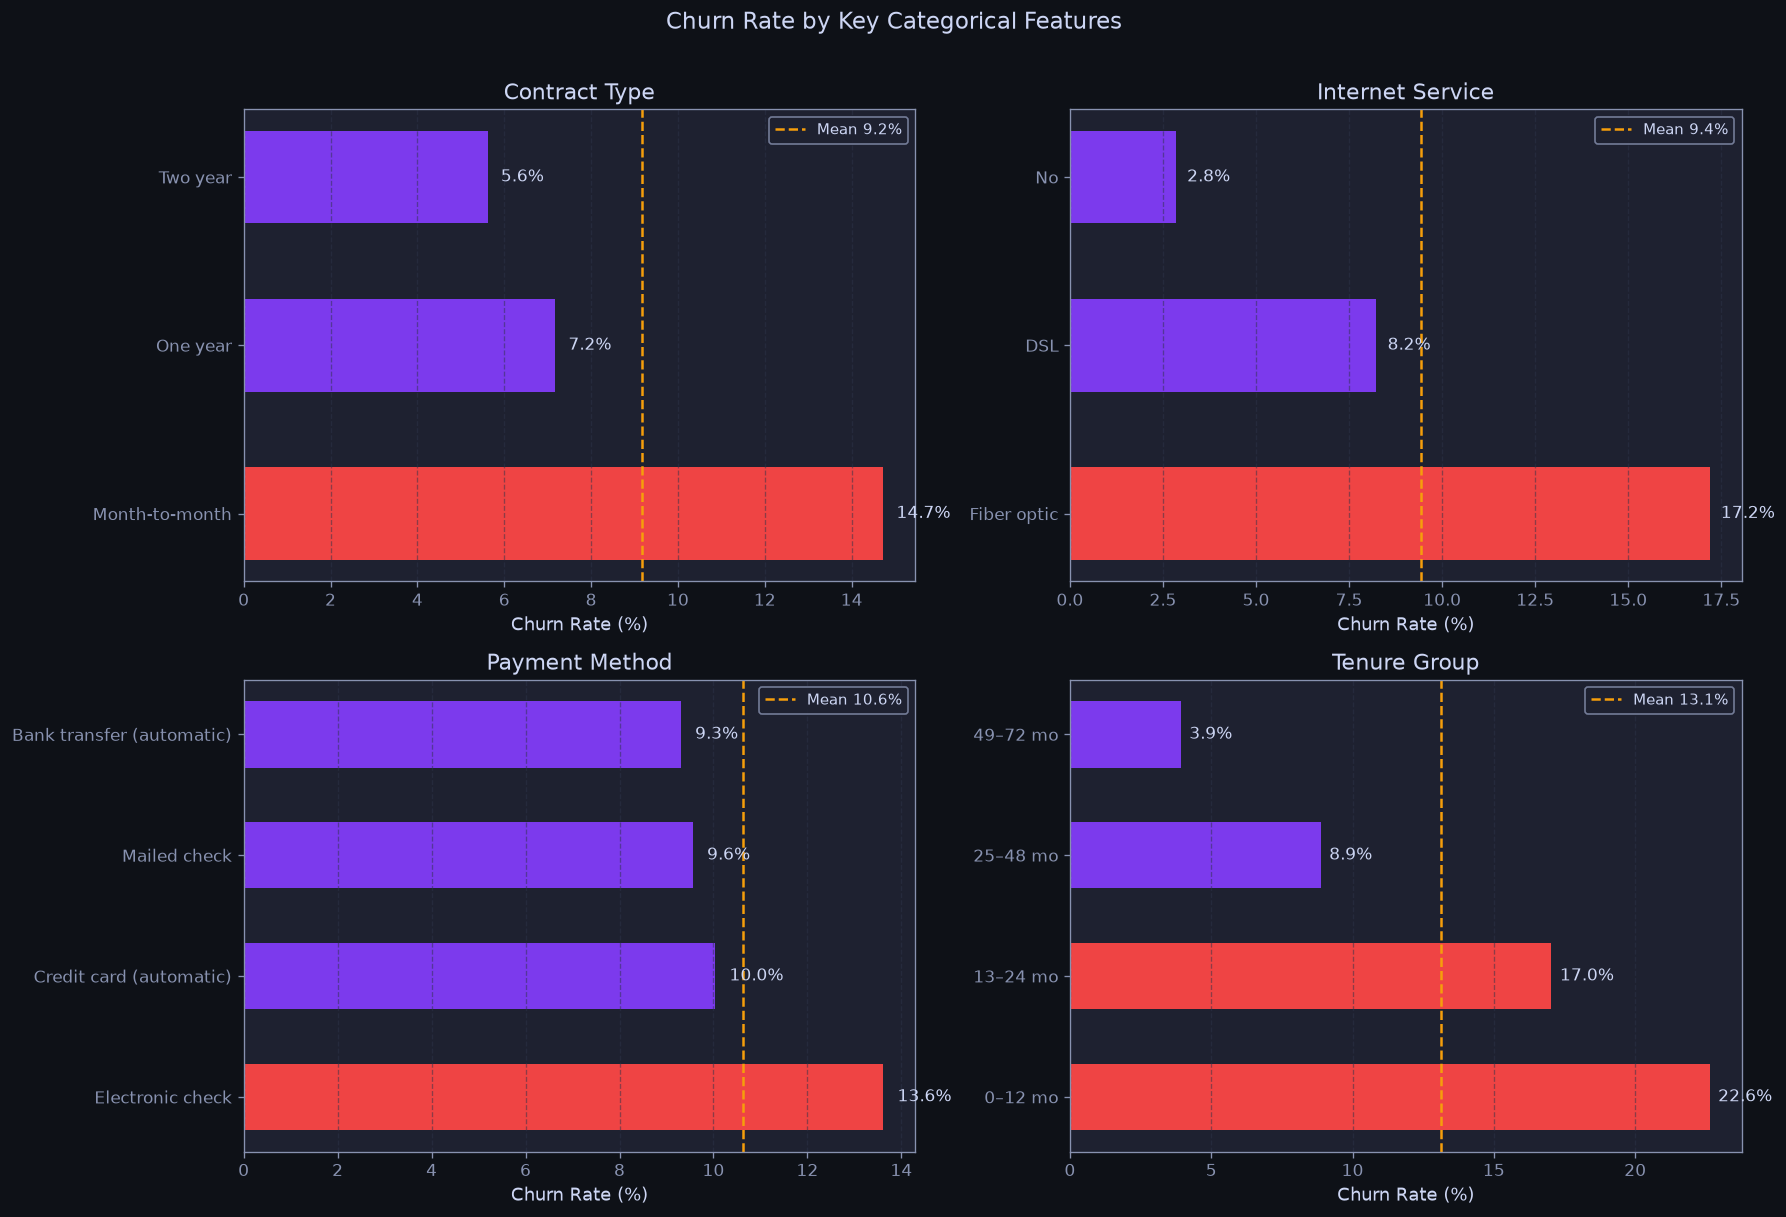

In [10]:
# Churn rate by every categorical feature
cat_features = [
    ('contract',         'Contract Type'),
    ('internet_service', 'Internet Service'),
    ('payment_method',   'Payment Method'),
    ('tenure_group',     'Tenure Group'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Churn Rate by Key Categorical Features', fontsize=14, color=TEXT, y=1.01)
axes = axes.flatten()

for ax, (col, label) in zip(axes, cat_features):
    churn_rates = (
        df.groupby(col)['churn']
        .mean()
        .sort_values(ascending=False)
        .mul(100)
    )
    bars = ax.barh(
        churn_rates.index.astype(str),
        churn_rates.values,
        color=[DANGER if v > churn_rates.mean() else PRIMARY for v in churn_rates.values],
        height=0.55,
    )
    ax.axvline(churn_rates.mean(), color=WARNING, linestyle='--', lw=1.5,
               label=f'Mean {churn_rates.mean():.1f}%')
    for bar, val in zip(bars, churn_rates.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=10, color=TEXT)
    ax.set_title(label)
    ax.set_xlabel('Churn Rate (%)')
    ax.legend(fontsize=9)
    ax.grid(axis='x')

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_cat_churn.png', bbox_inches='tight')
plt.show()

In [11]:
# Full churn rate table for all binary/multi-category features
rows = []
for col in CAT_COLS:
    for val, grp in df.groupby(col)['churn']:
        rows.append({
            'Feature': col,
            'Value':   str(val),
            'N':       len(grp),
            'Churned': grp.sum(),
            'Churn %': round(grp.mean() * 100, 1),
        })

churn_table = pd.DataFrame(rows).sort_values(['Feature', 'Churn %'], ascending=[True, False])
churn_table.style.background_gradient(subset=['Churn %'], cmap='RdYlGn_r')

,Feature,Value,N,Churned,Churn %
34,contract,Month-to-month,3890,573,14.700000
35,contract,One year,1463,105,7.200000
36,contract,Two year,1690,95,5.600000
7,dependents,Yes,2067,234,11.300000
6,dependents,No,4976,539,10.800000
22,device_protection,No,3619,499,13.800000
24,device_protection,Yes,1844,229,12.400000
23,device_protection,No internet service,1580,45,2.800000
1,gender,Male,3567,399,11.200000
0,gender,Female,3476,374,10.800000


## 6 · Bivariate Analysis — Features vs Churn

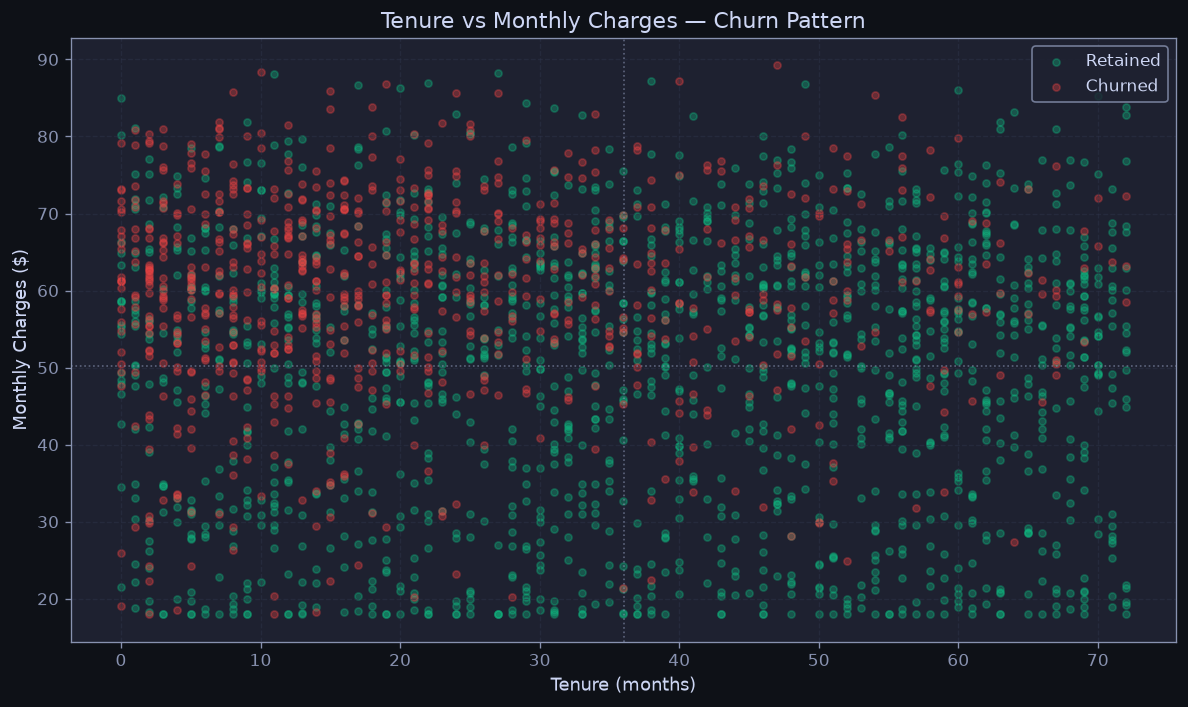

High risk zone (tenure<12, charges>$60): 32.9% churn rate


In [12]:
# Scatter: Tenure vs Monthly Charges, coloured by churn
fig, ax = plt.subplots(figsize=(10, 6))

for churn_val, label, color in [(0, 'Retained', SUCCESS), (1, 'Churned', DANGER)]:
    sub = df[df['churn'] == churn_val].sample(min(1500, (df['churn'] == churn_val).sum()), random_state=42)
    ax.scatter(sub['tenure'], sub['monthly_charges'],
               alpha=0.35, s=18, c=color, label=label)

ax.set_title('Tenure vs Monthly Charges — Churn Pattern', fontsize=13)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.legend()
ax.grid(True)
ax.axvline(df['tenure'].mean(), color=MUTED, linestyle=':', lw=1, alpha=0.6, label='Mean tenure')
ax.axhline(df['monthly_charges'].mean(), color=MUTED, linestyle=':', lw=1, alpha=0.6)

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_scatter.png', bbox_inches='tight')
plt.show()

print(f"High risk zone (tenure<12, charges>$60): "
      f"{df.loc[(df['tenure']<12) & (df['monthly_charges']>60), 'churn'].mean()*100:.1f}% churn rate")

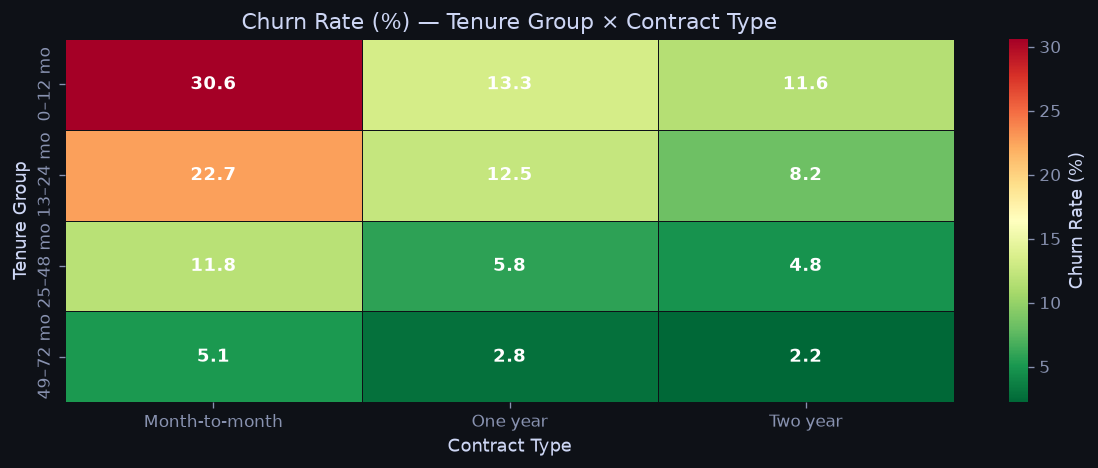

In [13]:
# Churn rate by tenure group × contract type (heatmap)
pivot = (
    df.groupby(['tenure_group', 'contract'])['churn']
    .mean()
    .mul(100)
    .round(1)
    .unstack('contract')
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=0.5,
    linecolor=DARK_BG,
    cbar_kws={'label': 'Churn Rate (%)'},
    annot_kws={'size': 11, 'color': 'white', 'weight': 'bold'},
)
ax.set_title('Churn Rate (%) — Tenure Group × Contract Type', fontsize=13)
ax.set_xlabel('Contract Type')
ax.set_ylabel('Tenure Group')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_heatmap_tenure_contract.png', bbox_inches='tight')
plt.show()

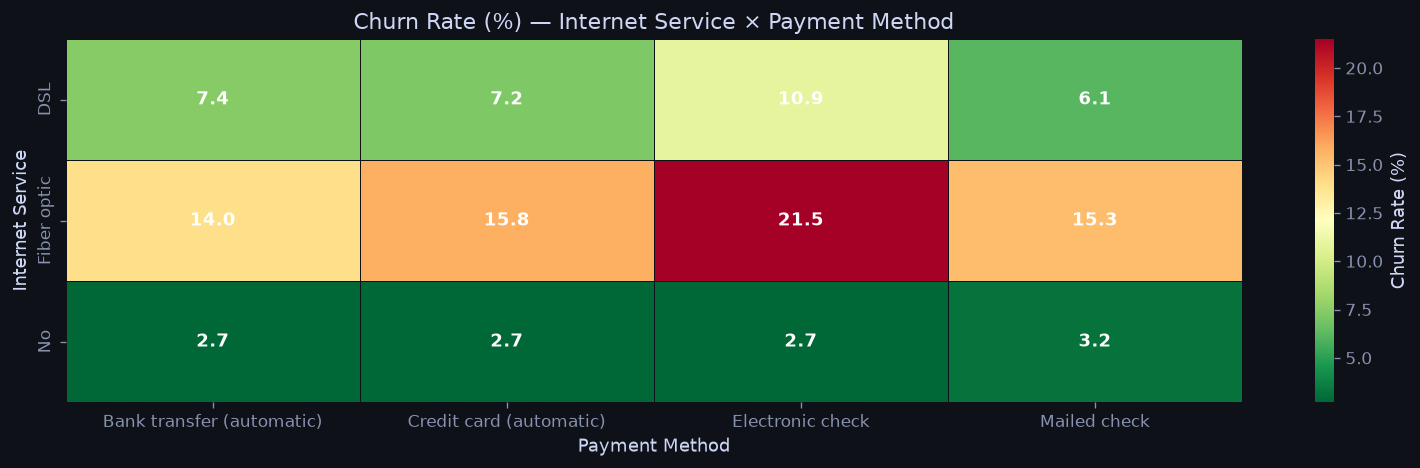

In [14]:
# Internet service × payment method churn matrix
pivot2 = (
    df.groupby(['internet_service', 'payment_method'])['churn']
    .mean()
    .mul(100)
    .round(1)
    .unstack('payment_method')
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot2,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=0.5,
    linecolor=DARK_BG,
    cbar_kws={'label': 'Churn Rate (%)'},
    annot_kws={'size': 11, 'color': 'white', 'weight': 'bold'},
)
ax.set_title('Churn Rate (%) — Internet Service × Payment Method', fontsize=13)
ax.set_xlabel('Payment Method')
ax.set_ylabel('Internet Service')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_heatmap_inet_pay.png', bbox_inches='tight')
plt.show()

## 7 · Correlation & Multicollinearity

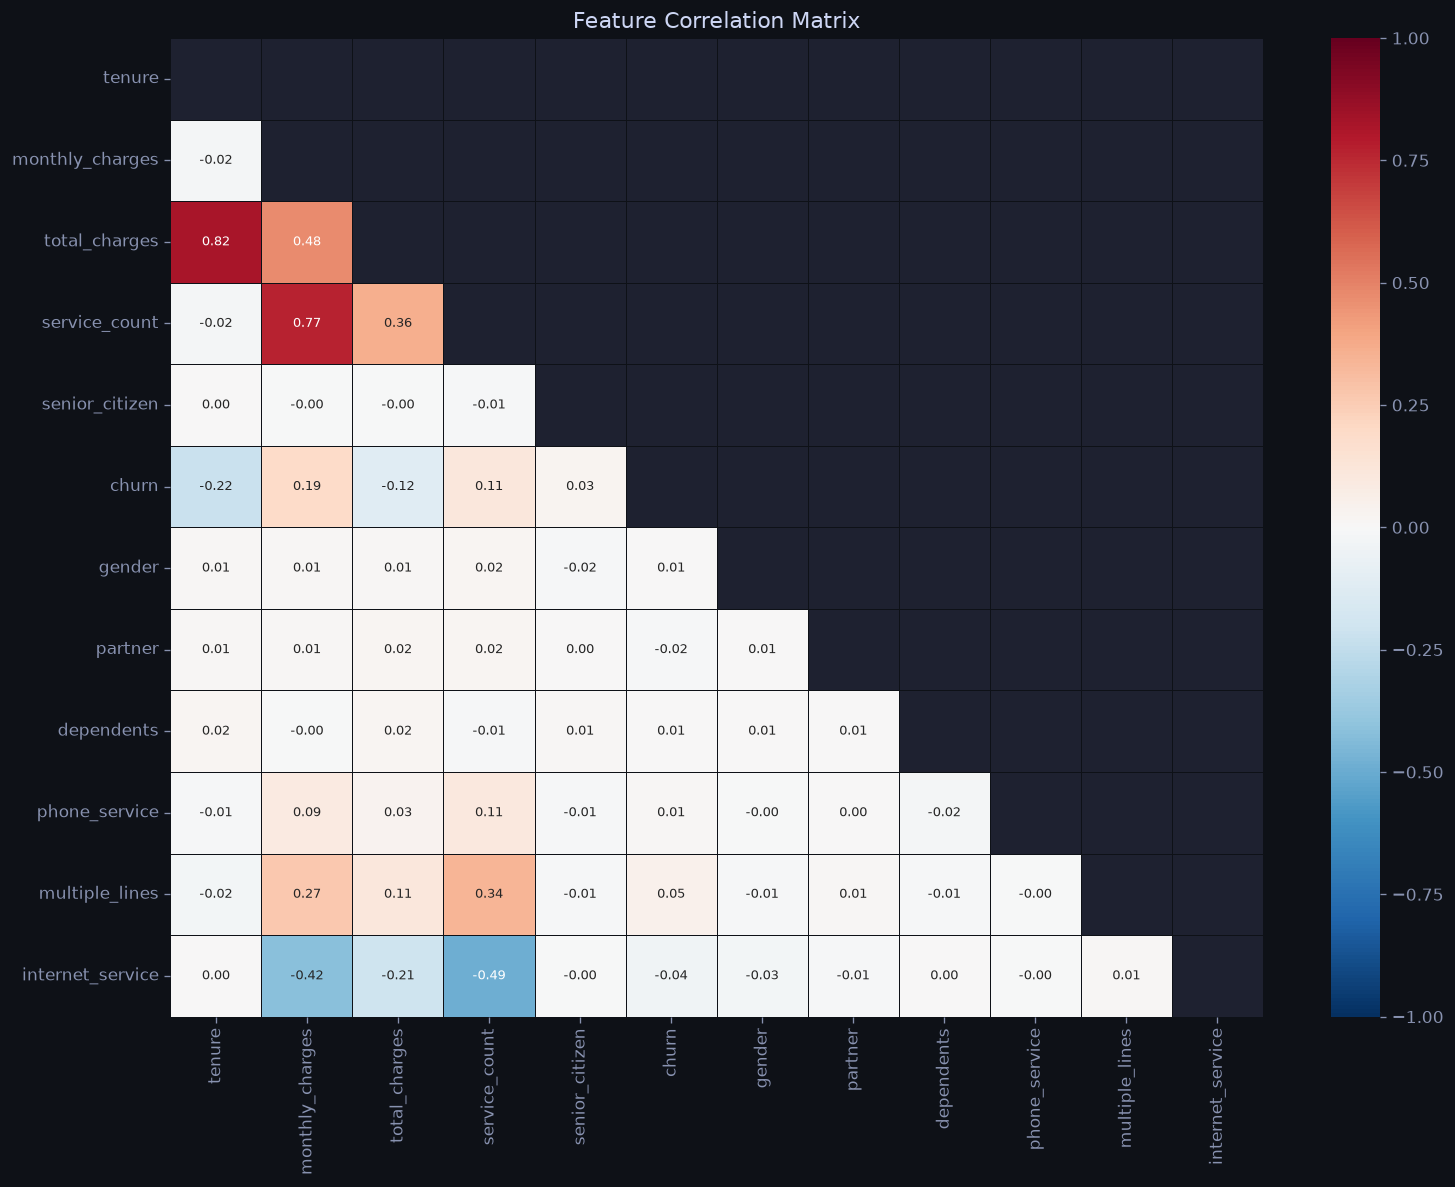

In [15]:
# Encode all features numerically for correlation analysis
from sklearn.preprocessing import OrdinalEncoder

df_enc = df.copy()
cat_to_encode = [c for c in CAT_COLS if df_enc[c].dtype == object]
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_enc[cat_to_encode] = enc.fit_transform(df_enc[cat_to_encode])

corr_cols = NUM_COLS + ['senior_citizen', 'churn'] + cat_to_encode[:6]
corr = df_enc[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    linewidths=0.4,
    linecolor=DARK_BG,
    annot_kws={'size': 8},
    vmin=-1, vmax=1,
)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_correlation.png', bbox_inches='tight')
plt.show()

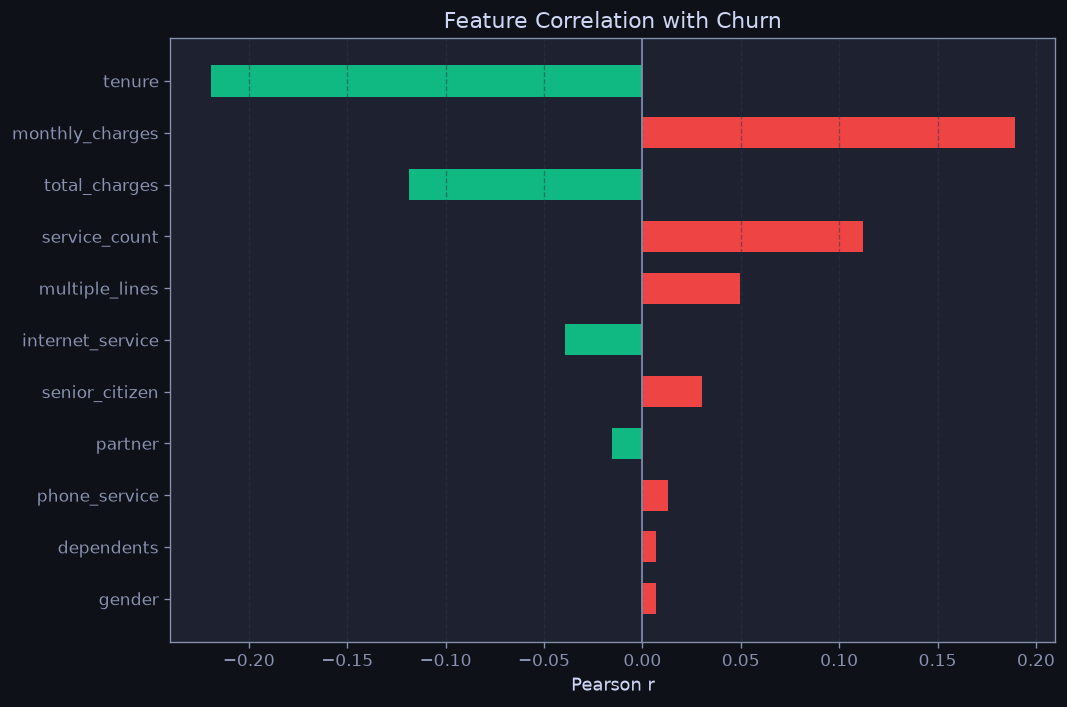

Top 5 positive correlates with churn:
monthly_charges    0.189324
service_count      0.111879
multiple_lines     0.049818
senior_citizen     0.030392
phone_service      0.012796

Top 5 negative correlates with churn:
tenure             -0.219452
total_charges      -0.118491
internet_service   -0.039213
partner            -0.015580


In [16]:
# Top correlations with churn
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [DANGER if v > 0 else SUCCESS for v in churn_corr.values]
ax.barh(churn_corr.index[::-1], churn_corr.values[::-1], color=colors_bar[::-1], height=0.6)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_title('Feature Correlation with Churn', fontsize=13)
ax.set_xlabel('Pearson r')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_churn_corr.png', bbox_inches='tight')
plt.show()

print('Top 5 positive correlates with churn:')
print(churn_corr[churn_corr > 0].head(5).to_string())
print('\nTop 5 negative correlates with churn:')
print(churn_corr[churn_corr < 0].head(5).to_string())

## 8 · Customer Segmentation Insights

In [17]:
# Risk segment breakdown
def assign_risk(row):
    score = 0
    if row['contract'] == 'Month-to-month': score += 3
    if row['internet_service'] == 'Fiber optic': score += 2
    if row['payment_method'] == 'Electronic check': score += 2
    if row['tenure'] < 12: score += 2
    if row['monthly_charges'] > 70: score += 1
    if row['online_security'] == 'No': score += 1
    if row['tech_support'] == 'No': score += 1
    if score >= 7: return 'High Risk'
    if score >= 4: return 'Medium Risk'
    return 'Low Risk'

df['risk_segment'] = df.apply(assign_risk, axis=1)

seg = df.groupby('risk_segment').agg(
    customers=('churn', 'count'),
    churn_rate=('churn', 'mean'),
    avg_monthly_charges=('monthly_charges', 'mean'),
    avg_tenure=('tenure', 'mean'),
).round(2)
seg['churn_rate'] = (seg['churn_rate'] * 100).round(1)
seg = seg.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
print(seg.to_string())

              customers  churn_rate  avg_monthly_charges  avg_tenure
risk_segment                                                        
High Risk          1835        23.0                60.18       30.66
Medium Risk        2929        10.0                52.78       36.26
Low Risk           2279         3.0                39.02       40.10


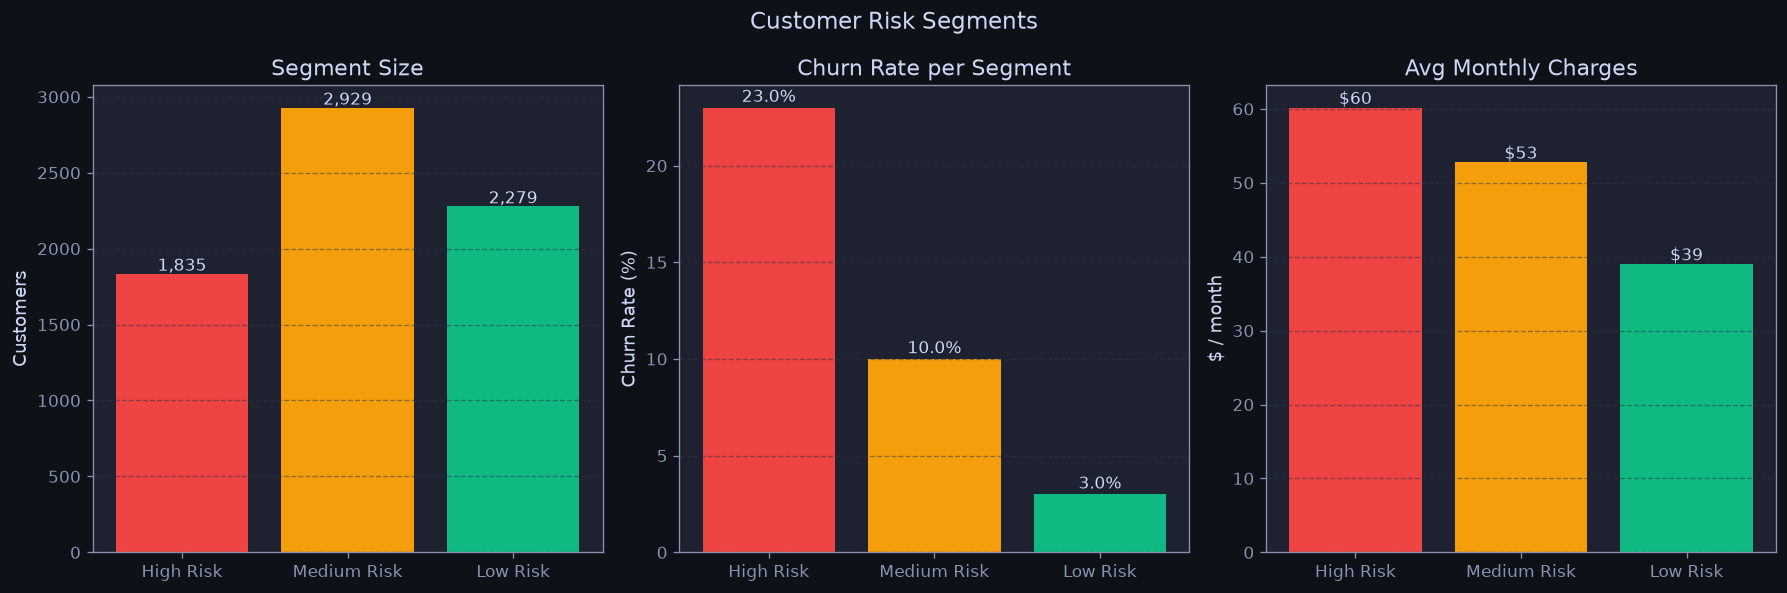

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Risk Segments', fontsize=14, color=TEXT)

seg_colors = [DANGER, WARNING, SUCCESS]
seg_order  = ['High Risk', 'Medium Risk', 'Low Risk']

# Segment sizes
axes[0].bar(seg_order, seg['customers'], color=seg_colors)
for i, v in enumerate(seg['customers']):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', color=TEXT, fontsize=10)
axes[0].set_title('Segment Size')
axes[0].set_ylabel('Customers')
axes[0].grid(axis='y')

# Churn rates
axes[1].bar(seg_order, seg['churn_rate'], color=seg_colors)
for i, v in enumerate(seg['churn_rate']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', color=TEXT, fontsize=10)
axes[1].set_title('Churn Rate per Segment')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].grid(axis='y')

# Avg monthly charges
axes[2].bar(seg_order, seg['avg_monthly_charges'], color=seg_colors)
for i, v in enumerate(seg['avg_monthly_charges']):
    axes[2].text(i, v + 0.5, f'${v:.0f}', ha='center', color=TEXT, fontsize=10)
axes[2].set_title('Avg Monthly Charges')
axes[2].set_ylabel('$ / month')
axes[2].grid(axis='y')

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_segments.png', bbox_inches='tight')
plt.show()

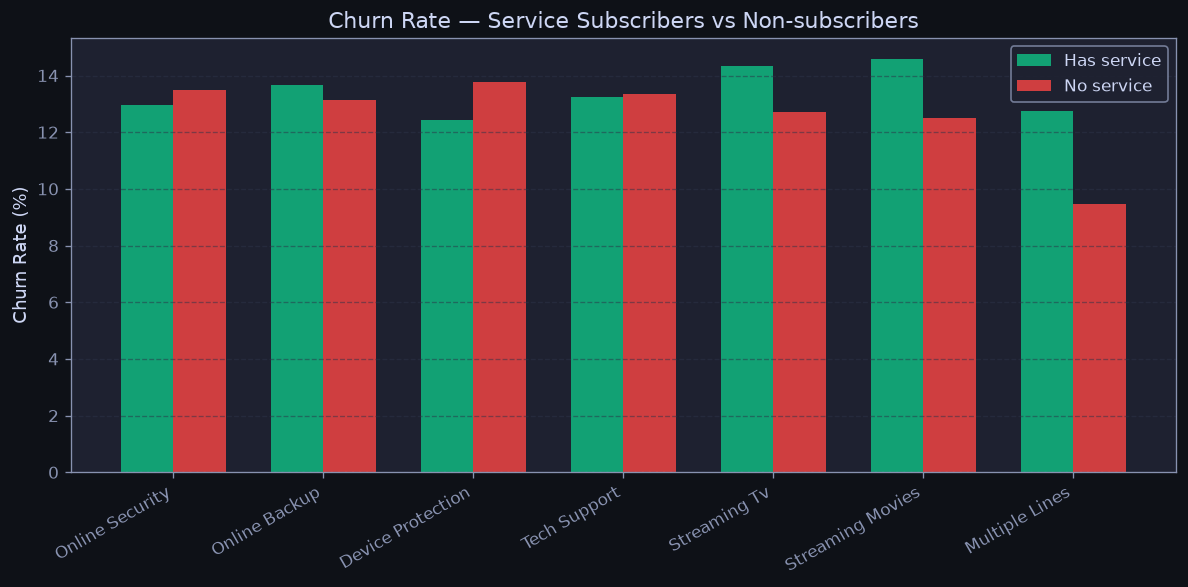

In [19]:
# Service adoption analysis
fig, ax = plt.subplots(figsize=(10, 5))

svc_churn = {}
for col in SERVICE_COLS:
    rate_yes = df.loc[df[col] == 'Yes', 'churn'].mean() * 100
    rate_no  = df.loc[df[col] == 'No',  'churn'].mean() * 100
    svc_churn[col.replace('_', ' ').title()] = (rate_yes, rate_no)

names   = list(svc_churn.keys())
yes_rates = [v[0] for v in svc_churn.values()]
no_rates  = [v[1] for v in svc_churn.values()]
x = np.arange(len(names))
w = 0.35

ax.bar(x - w/2, yes_rates, w, label='Has service', color=SUCCESS, alpha=0.85)
ax.bar(x + w/2, no_rates,  w, label='No service',  color=DANGER,  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_title('Churn Rate — Service Subscribers vs Non-subscribers', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_service_churn.png', bbox_inches='tight')
plt.show()

## 9 · Key Findings & Modelling Implications

### 🔴 High-risk signals
| Factor | Finding |
|---|---|
| **Contract type** | Month-to-month customers churn at ~3× the rate of two-year contracts |
| **Tenure** | Most churners leave within the first 12 months — early intervention is critical |
| **Fiber optic** | Highest churn among internet service types — possible satisfaction issue |
| **Electronic check** | Highest churn of all payment methods — possibly lower switching cost |
| **No online security / tech support** | Customers without these protective services churn more |

### 🟡 Moderate signals
| Factor | Finding |
|---|---|
| **Monthly charges > $70** | Above-average charges correlate with higher churn |
| **Senior citizens** | Slightly higher churn rate (confirmed by H4 hypothesis test) |
| **No partner / dependents** | Slightly higher churn — may indicate fewer switching costs |

### 🟢 Protective factors
| Factor | Finding |
|---|---|
| **Two-year contract** | Lowest churn across all contract types |
| **Long tenure (>48 mo)** | Customers who stay 4+ years are highly stable |
| **Multiple services** | Customers with 5+ services churn less (higher stickiness) |
| **Auto-payment methods** | Bank transfer & credit card auto-pay correlated with lower churn |

### 📐 Modelling implications
- **Class imbalance** (~11% churn) requires `scale_pos_weight` or oversampling (SMOTE)
- **Feature engineering** for `tenure_group`, `service_count`, and `charges_per_month_ratio` should add predictive signal
- **Threshold tuning** — default 0.5 will miss too many churners; calibrate toward recall
- **Interaction terms** — tenure × contract and charges × internet_service combinations are strong

In [20]:
# Final summary stats
print('=== EDA Summary ===')
print(f"Dataset          : {len(df):,} customers")
print(f"Overall churn    : {df['churn'].mean()*100:.1f}%")
print(f"High-risk segment: {(df['risk_segment']=='High Risk').sum():,} customers "
      f"({(df['risk_segment']=='High Risk').mean()*100:.1f}%) "
      f"→ churn rate {df.loc[df['risk_segment']=='High Risk','churn'].mean()*100:.1f}%")
print(f"Strongest predictor : monthly_charges  (r={corr['churn']['monthly_charges']:.3f})")
print(f"Best protective factor : tenure       (r={corr['churn']['tenure']:.3f})")

=== EDA Summary ===
Dataset          : 7,043 customers
Overall churn    : 11.0%
High-risk segment: 1,835 customers (26.1%) → churn rate 23.1%
Strongest predictor : monthly_charges  (r=0.189)
Best protective factor : tenure       (r=-0.219)
